In [ ]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas
!pip install openmeteo-requests requests-cache pandas numpy tensorflow scikit-learn schedule


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.3 MB/s eta 0:00:00


Training: GRU_Attention
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step
Training: LSTM
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Training: CNN_GRU
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Training: Dense
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

🏁 Comparison Table:
           Model       MSE       MAE        R2
0  GRU_Attention  1.411095  0.921230  0.957649
1           LSTM  2.328713  1.163737  0.930076
2        CNN_GRU  3.143512  1.394257  0.905616
3          Dense  3.244445  1.341470  0.902572


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


<ipython-input-3-7155f92616d7>:167: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_times = pd.date_range(start=last_timestamp, periods=PREDICTION_HORIZON+1, freq="H")[1:]
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


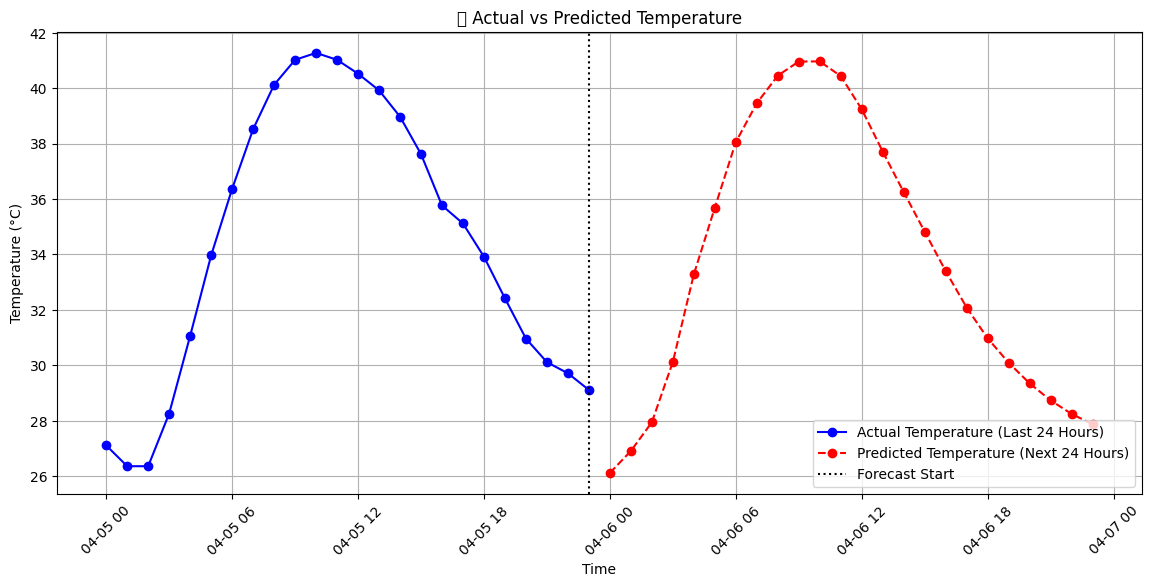

In [ ]:
import openmeteo_requests
import requests_cache
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Attention, Input, TimeDistributed, RepeatVector, Conv1D, Flatten, BatchNormalization, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Setup Open-Meteo API client
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
openmeteo = openmeteo_requests.Client(session=cache_session)

PREDICTION_HORIZON = 24

def fetch_and_preprocess():
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 23.0258,
        "longitude": 72.5873,
        "start_date": "2024-02-11",
        "end_date": "2025-04-05",
        "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", "wind_speed_10m", "cloud_cover", "surface_pressure"]
    }
    responses = openmeteo.weather_api(url, params=params)
    if not responses:
        return None

    response = responses[0]
    hourly = response.Hourly()
    data = {
        "date": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        ),
        "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
        "relative_humidity_2m": hourly.Variables(1).ValuesAsNumpy(),
        "precipitation": hourly.Variables(2).ValuesAsNumpy(),
        "rain": hourly.Variables(3).ValuesAsNumpy(),
        "snowfall": hourly.Variables(4).ValuesAsNumpy(),
        "wind_speed_10m": hourly.Variables(5).ValuesAsNumpy(),
        "cloud_cover": hourly.Variables(6).ValuesAsNumpy(),
        "surface_pressure": hourly.Variables(7).ValuesAsNumpy()
    }
    df = pd.DataFrame(data)
    df.set_index("date", inplace=True)
    df.dropna(inplace=True)

    # ⏰ Add time features
    df["hour"] = df.index.hour
    df["day_of_year"] = df.index.dayofyear
    df["weekday"] = df.index.weekday

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["day_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["day_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

    df.drop(columns=["hour", "day_of_year", "weekday"], inplace=True)
    return df

def build_model(model_type, input_shape):
    inputs = Input(shape=input_shape)

    if model_type == "GRU_Attention":
        x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = GRU(100, return_sequences=True, activation='relu')(x)
        x = Attention()([x, x])
        x = Dropout(0.3)(x)
        x = GRU(100, activation='relu')(x)
        x = RepeatVector(PREDICTION_HORIZON)(x)
        x = GRU(100, return_sequences=True, activation='relu')(x)
        x = TimeDistributed(Dense(50, activation='relu'))(x)

    elif model_type == "LSTM":
        x = LSTM(128, return_sequences=False)(inputs)
        x = RepeatVector(PREDICTION_HORIZON)(x)
        x = LSTM(64, return_sequences=True)(x)
        x = TimeDistributed(Dense(50, activation='relu'))(x)

    elif model_type == "CNN_GRU":
        x = Conv1D(32, 3, activation='relu', padding='same')(inputs)
        x = GRU(64, return_sequences=False)(x)
        x = RepeatVector(PREDICTION_HORIZON)(x)
        x = GRU(64, return_sequences=True)(x)
        x = TimeDistributed(Dense(50, activation='relu'))(x)

    elif model_type == "Dense":
        x = Flatten()(inputs)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.2)(x)
        x = Dense(PREDICTION_HORIZON)(x)
        from tensorflow.keras.layers import Lambda
        x = Lambda(lambda t: tf.expand_dims(t, -1))(x)

    outputs = TimeDistributed(Dense(1))(x) if model_type != "Dense" else x

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

def prepare_data(df):
    X = df.drop(columns=["temperature_2m"])
    y = df["temperature_2m"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq, y_seq = [], []
    for i in range(len(X_scaled) - PREDICTION_HORIZON):
        X_seq.append(X_scaled[i:i+PREDICTION_HORIZON])
        y_seq.append(y.iloc[i+1:i+1+PREDICTION_HORIZON].values)

    X_train, X_test, y_train, y_test = train_test_split(np.array(X_seq), np.array(y_seq), test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test, scaler, X, df.index[-1]

def evaluate_all_models(X_train, X_test, y_train, y_test):
    models = ["GRU_Attention", "LSTM", "CNN_GRU", "Dense"]
    results = []

    best_model = None
    best_mse = float("inf")

    for model_type in models:
        print(f"Training: {model_type}")
        model = build_model(model_type, (PREDICTION_HORIZON, X_train.shape[2]))
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
        y_pred = model.predict(X_test).reshape(-1, PREDICTION_HORIZON)
        y_true = y_test.reshape(-1, PREDICTION_HORIZON)

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        results.append({"Model": model_type, "MSE": mse, "MAE": mae, "R2": r2})

        if mse < best_mse:
            best_model = model
            best_mse = mse
            best_model_type = model_type

    return pd.DataFrame(results), best_model, best_model_type

# 😎 NEW FUNCTION: Plot actual vs predicted temperature graph
def plot_actual_and_predicted(best_model, scaler, df):
    # 📉 Last 24 hours actual temperature
    actual_last = df["temperature_2m"].iloc[-PREDICTION_HORIZON:]
    actual_times = df.index[-PREDICTION_HORIZON:]

    # 🚀 Prepare latest input for prediction (last 24 hours features)
    latest_data = df.drop(columns=["temperature_2m"]).iloc[-PREDICTION_HORIZON:].values
    latest_scaled = scaler.transform(latest_data)
    latest_reshaped = latest_scaled.reshape((1, latest_scaled.shape[0], latest_scaled.shape[1]))
    prediction = best_model.predict(latest_reshaped).flatten()

    # ⏱️ Generate future timestamps (next 24 hours)
    last_timestamp = df.index[-1]
    future_times = pd.date_range(start=last_timestamp, periods=PREDICTION_HORIZON+1, freq="H")[1:]

    # 🎨 Plot both actual and predicted temperatures on one graph
    plt.figure(figsize=(14,6))
    plt.plot(actual_times, actual_last, marker='o', linestyle='-', color='b', label='Actual Temperature (Last 24 Hours)')
    plt.plot(future_times, prediction, marker='o', linestyle='--', color='r', label='Predicted Temperature (Next 24 Hours)')
    plt.axvline(x=last_timestamp, color='k', linestyle=':', label='Forecast Start')
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.title("🔥 Actual vs Predicted Temperature")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

# === Run Pipeline ===
df = fetch_and_preprocess()
if df is not None:
    X_train, X_test, y_train, y_test, scaler, X, last_timestamp = prepare_data(df)
    result_df, best_model, best_name = evaluate_all_models(X_train, X_test, y_train, y_test)
    print("\n🏁 Comparison Table:")
    print(result_df.sort_values("MSE"))
    # 🎯 Plot the last 24 hours actual temperature and next 24 hours predicted temperature
    plot_actual_and_predicted(best_model, scaler, df)
else:
    print("Failed to fetch weather data.")


Training: GRU_Attention
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step
Training: LSTM
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Training: CNN_GRU
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Training: Dense
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


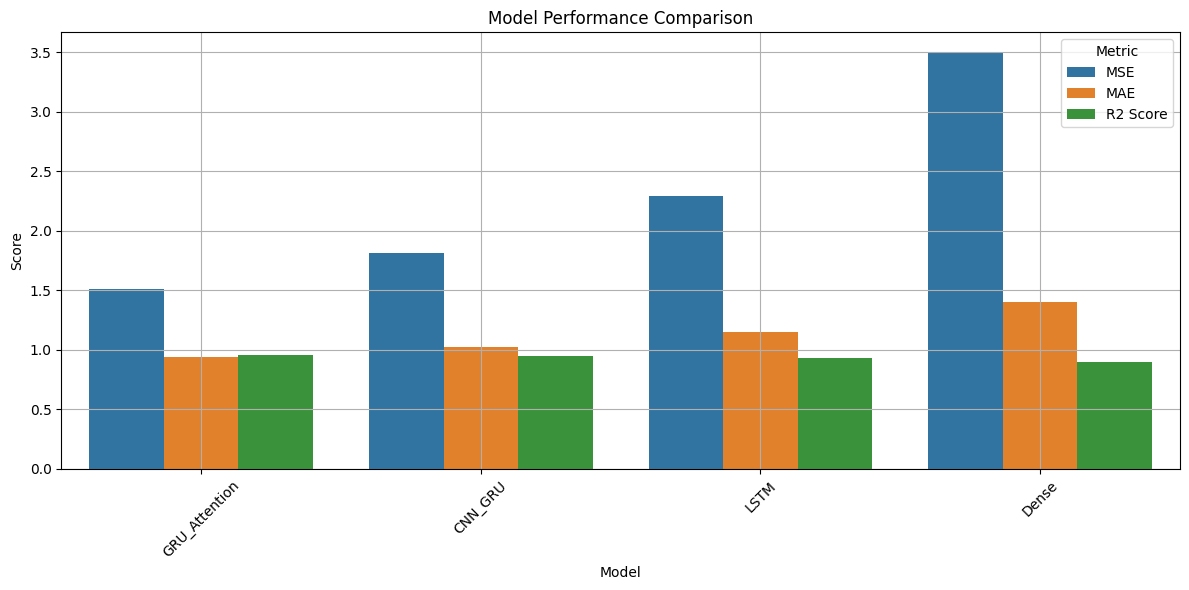

(           Model       MSE       MAE  R2 Score
 0  GRU_Attention  1.510143  0.943971  0.954652
 2        CNN_GRU  1.815937  1.020129  0.945467
 1           LSTM  2.291239  1.146575  0.931213
 3          Dense  3.494392  1.399776  0.895066,
 <Functional name=functional_4, built=True>,
 'GRU_Attention')

In [ ]:
import seaborn as sns

def evaluate_all_models(X_train, X_test, y_train, y_test):
    models = ["GRU_Attention", "LSTM", "CNN_GRU", "Dense"]
    results = []

    best_model = None
    best_mse = float("inf")

    for model_type in models:
        print(f"Training: {model_type}")
        model = build_model(model_type, (PREDICTION_HORIZON, X_train.shape[2]))
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
        y_pred = model.predict(X_test).reshape(-1, PREDICTION_HORIZON)
        y_true = y_test.reshape(-1, PREDICTION_HORIZON)

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        results.append({
            "Model": model_type,
            "MSE": mse,
            "MAE": mae,
            "R2 Score": r2
        })

        if mse < best_mse:
            best_model = model
            best_mse = mse
            best_model_type = model_type

    result_df = pd.DataFrame(results).sort_values(by="MSE")

    # --- Plot Comparison ---
    plt.figure(figsize=(12, 6))
    melted_df = result_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
    sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric")
    plt.title("Model Performance Comparison")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return result_df, best_model, best_model_type
evaluate_all_models(X_train, X_test, y_train, y_test)